<a href="https://colab.research.google.com/github/navin0744/power-bi/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [110]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_palette("Set2")

%matplotlib inline

In [111]:
data = pd.read_csv('/content/retail_sales_dataset.csv')

In [112]:
print(data.head())


   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  


In [113]:
print(data.tail)

<bound method NDFrame.tail of      Transaction ID        Date Customer ID  Gender  Age Product Category  \
0                 1  2023-11-24     CUST001    Male   34           Beauty   
1                 2  2023-02-27     CUST002  Female   26         Clothing   
2                 3  2023-01-13     CUST003    Male   50      Electronics   
3                 4  2023-05-21     CUST004    Male   37         Clothing   
4                 5  2023-05-06     CUST005    Male   30           Beauty   
..              ...         ...         ...     ...  ...              ...   
995             996  2023-05-16     CUST996    Male   62         Clothing   
996             997  2023-11-17     CUST997    Male   52           Beauty   
997             998  2023-10-29     CUST998  Female   23           Beauty   
998             999  2023-12-05     CUST999  Female   36      Electronics   
999            1000  2023-04-12    CUST1000    Male   47      Electronics   

     Quantity  Price per Unit  Total Amount  

In [114]:
print(data.shape)

(1000, 9)


In [115]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB
None


In [116]:
print(data.columns)

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')


In [117]:
print(data.describe(include='all'))

        Transaction ID        Date Customer ID  Gender         Age  \
count      1000.000000        1000        1000    1000  1000.00000   
unique             NaN         345        1000       2         NaN   
top                NaN  2023-05-16    CUST1000  Female         NaN   
freq               NaN          11           1     510         NaN   
mean        500.500000         NaN         NaN     NaN    41.39200   
std         288.819436         NaN         NaN     NaN    13.68143   
min           1.000000         NaN         NaN     NaN    18.00000   
25%         250.750000         NaN         NaN     NaN    29.00000   
50%         500.500000         NaN         NaN     NaN    42.00000   
75%         750.250000         NaN         NaN     NaN    53.00000   
max        1000.000000         NaN         NaN     NaN    64.00000   

       Product Category     Quantity  Price per Unit  Total Amount  
count              1000  1000.000000     1000.000000   1000.000000  
unique               

In [118]:
print(data.isnull().sum())

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [119]:
print(data.duplicated().sum())

0


In [120]:
print(data.drop_duplicates())

     Transaction ID        Date Customer ID  Gender  Age Product Category  \
0                 1  2023-11-24     CUST001    Male   34           Beauty   
1                 2  2023-02-27     CUST002  Female   26         Clothing   
2                 3  2023-01-13     CUST003    Male   50      Electronics   
3                 4  2023-05-21     CUST004    Male   37         Clothing   
4                 5  2023-05-06     CUST005    Male   30           Beauty   
..              ...         ...         ...     ...  ...              ...   
995             996  2023-05-16     CUST996    Male   62         Clothing   
996             997  2023-11-17     CUST997    Male   52           Beauty   
997             998  2023-10-29     CUST998  Female   23           Beauty   
998             999  2023-12-05     CUST999  Female   36      Electronics   
999            1000  2023-04-12    CUST1000    Male   47      Electronics   

     Quantity  Price per Unit  Total Amount  
0           3              50

In [121]:
numerical = data.select_dtypes(include=np.number)

stats = pd.DataFrame({
    "Mean": numerical.mean(),
    "Median": numerical.median(),
    "Mode": numerical.mode().iloc[0],
    "Std Dev": numerical.std()
})

stats

,Mean,Median,Mode,Std Dev
Transaction ID,500.500,500.5,1.0,288.819436
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


In [122]:
data['Date'] = pd.to_datetime(data['Date'])

In [123]:
data['Month'] = data['Date'].dt.to_period('M')

In [124]:
data['Quarter'] = data['Date'].dt.to_period('Q')

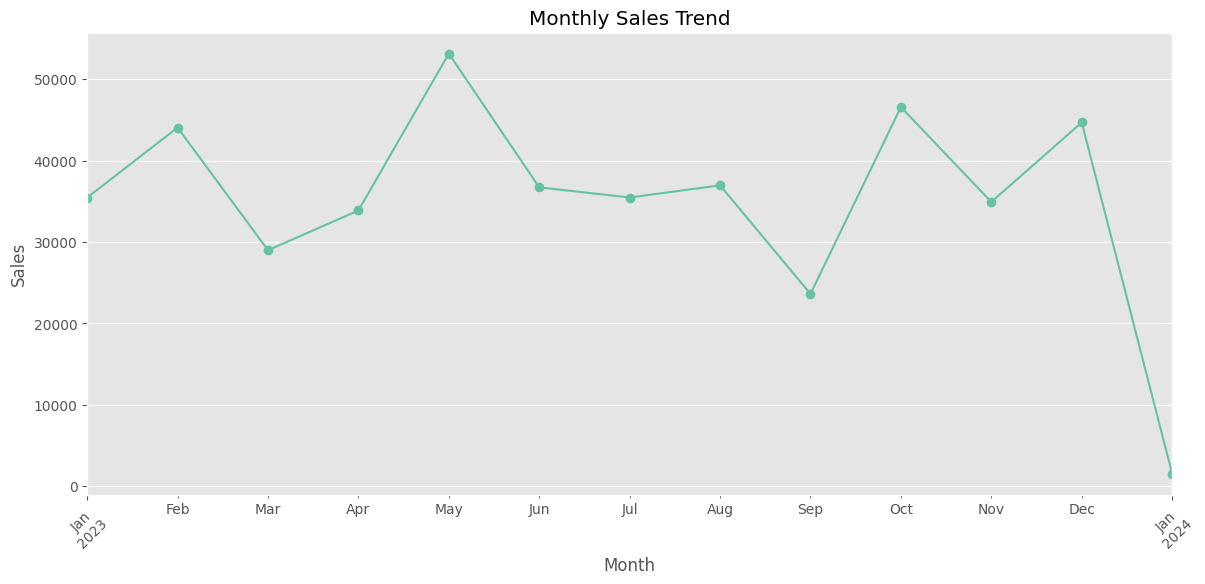

In [125]:
monthly_sales = data.groupby('Month')['Total Amount'].sum()

plt.figure(figsize=(14,6))

monthly_sales.plot(marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

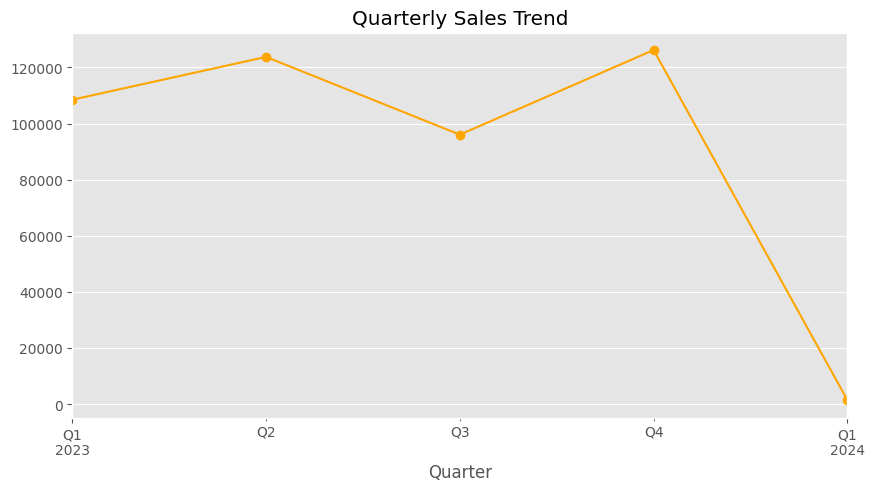

In [126]:
quarter_sales = data.groupby("Quarter")["Total Amount"].sum()

plt.figure(figsize=(10,5))

quarter_sales.plot(marker='o', color='orange')

plt.title("Quarterly Sales Trend")

plt.show()

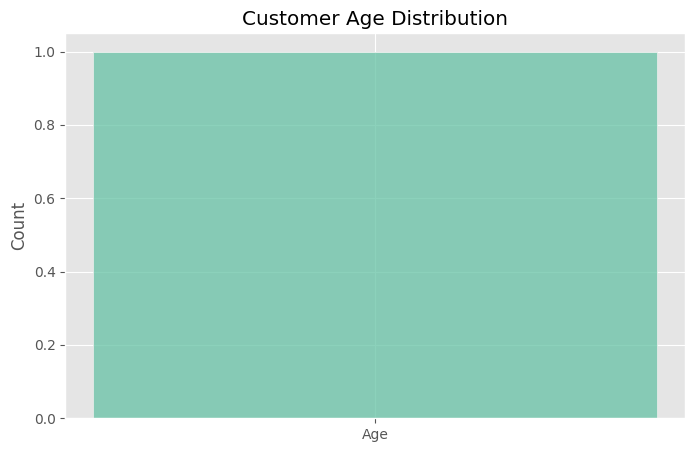

In [127]:
plt.figure(figsize=(8,5))

sns.histplot(data=["Age"], bins=20)

plt.title("Customer Age Distribution")

plt.show()

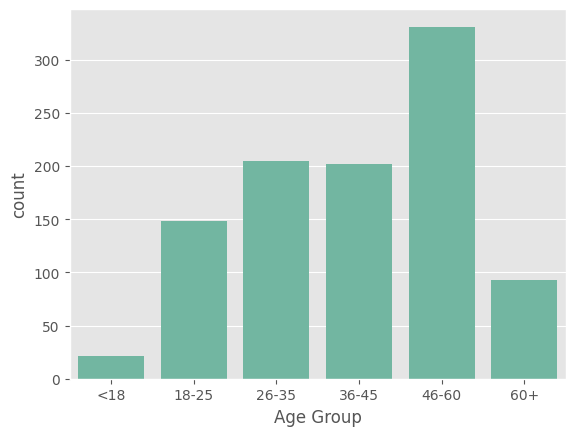

In [128]:
bins=[0,18,25,35,45,60,100]

labels=["<18","18-25","26-35","36-45","46-60","60+"]

data["Age Group"]=pd.cut(data["Age"],bins=bins,labels=labels)

sns.countplot(x="Age Group",data=data)

plt.show()

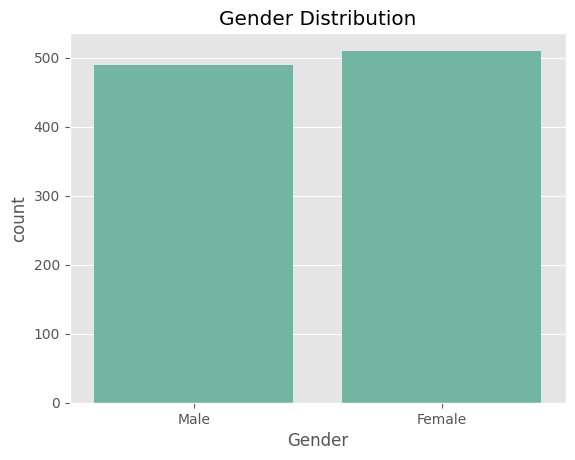

In [129]:
sns.countplot(x="Gender",data=data)

plt.title("Gender Distribution")

plt.show()

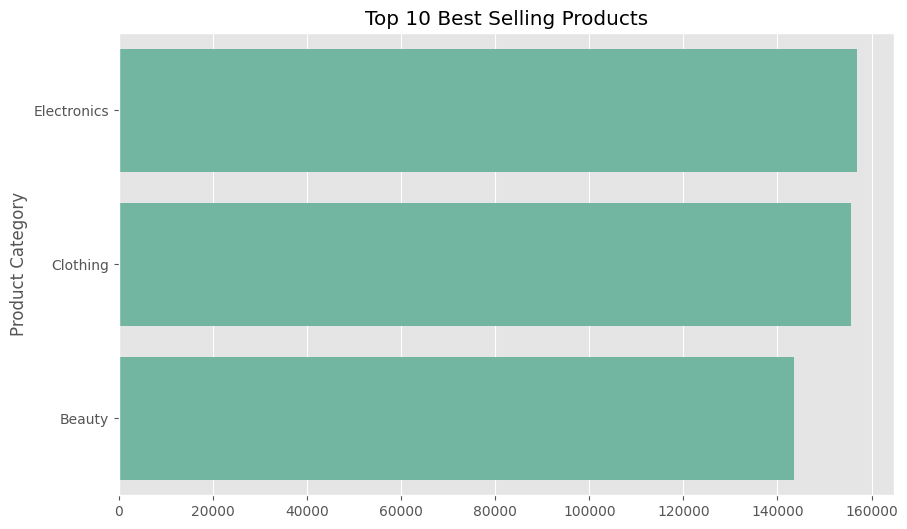

In [130]:
top_products = data.groupby("Product Category")["Total Amount"] \
                 .sum() \
                 .sort_values(ascending=False) \
                 .head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Best Selling Products")

plt.show()

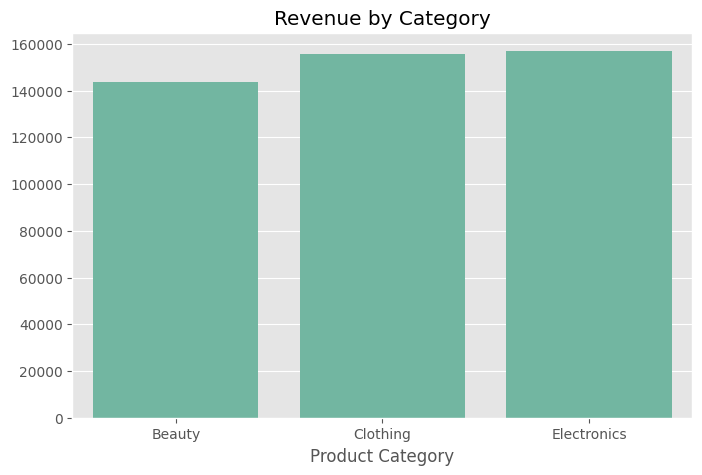

In [131]:
category_sales = data.groupby("Product Category")["Total Amount"].sum()

plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Revenue by Category")

plt.show()

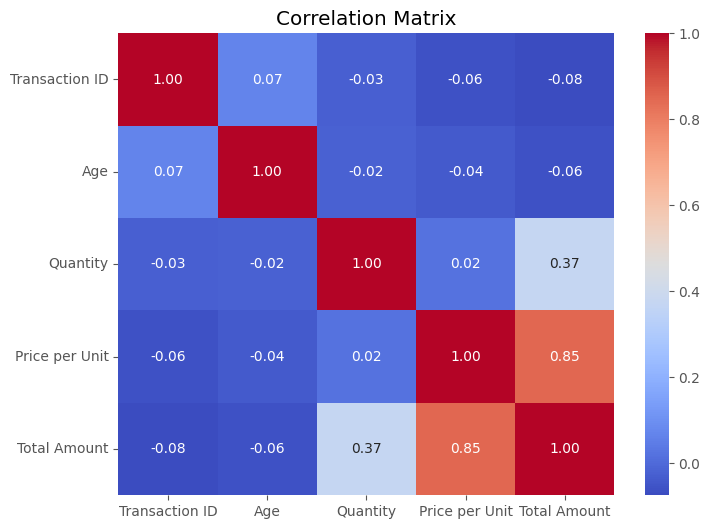

In [132]:
plt.figure(figsize=(8,6))

sns.heatmap(
    numerical.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

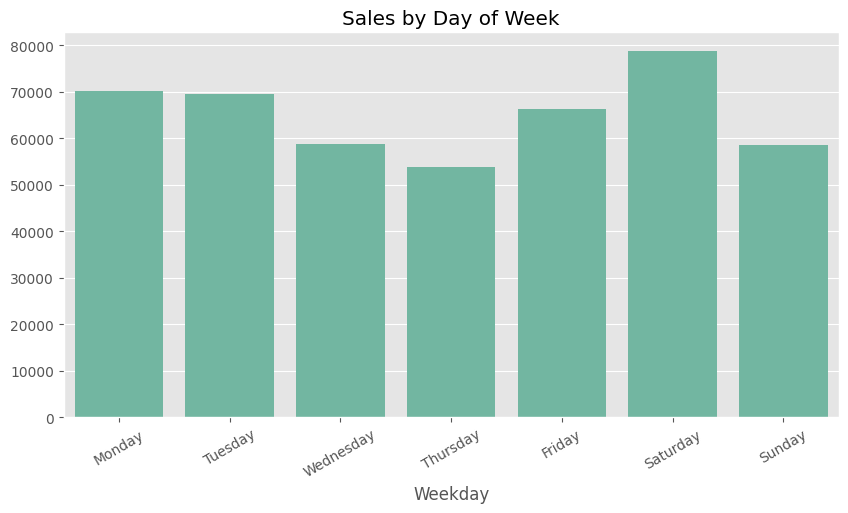

In [133]:
data["Weekday"] = data["Date"].dt.day_name()

weekday_sales = data.groupby("Weekday")["Total Amount"].sum().reindex([
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
])

plt.figure(figsize=(10,5))

sns.barplot(
    x=weekday_sales.index,
    y=weekday_sales.values
)

plt.xticks(rotation=30)

plt.title("Sales by Day of Week")

plt.show()

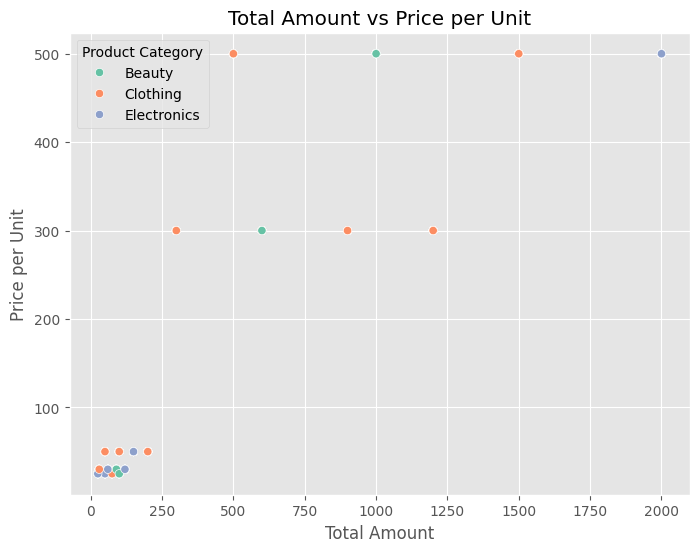

In [134]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=data,
    x="Total Amount",
    y="Price per Unit",
    hue="Product Category"
)

plt.title("Total Amount vs Price per Unit")

plt.show()

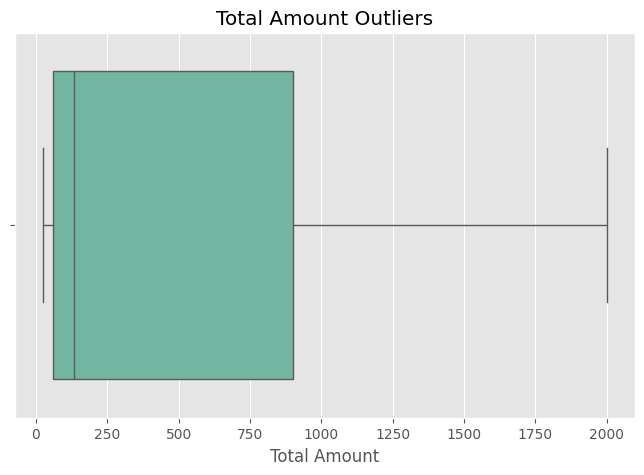

In [135]:
plt.figure(figsize=(8,5))

sns.boxplot(x=data["Total Amount"])

plt.title("Total Amount Outliers")

plt.show()